In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
train_data = pd.read_csv('data/canada_per_capita_income.csv')

In [3]:

eval_data = pd.read_csv('data/years.csv')

In [5]:
train_data.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [6]:
eval_data.head()

,year
0,1978
1,1979
2,1980
3,1981
4,1982


In [8]:
train_data.isnull().sum()


year                       0
per capita income (US$)    0
dtype: int64

In [9]:
eval_data.isnull().sum()

year    0
dtype: int64

In [11]:
train_data.columns

Index(['year', 'per capita income (US$)'], dtype='object')

In [12]:
eval_data.columns

Index(['year'], dtype='object')

In [24]:
X = train_data.drop(columns=['per capita income (US$)'])
y = train_data['per capita income (US$)']

In [36]:
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [37]:
model = LinearRegression()


In [38]:
model.fit(X_train, y_train)

LinearRegression()

In [40]:
y_pred = model.predict(x_test)
y_pred

array([23487.88766587, 27680.30003875, 25164.85261502,  3364.30827603,
       15103.0629201 ,  9233.68559806, 35226.64230994, 26003.3350896 ,
       18456.99281841,  8395.20312349])

In [41]:
pd.DataFrame({'y_test':y_test, 'y_pred':y_pred,"MAE":(y_test-y_pred)})

,y_test,y_pred,MAE
28,16622.671870,23487.887666,-6865.215796
33,22739.426280,27680.300039,-4940.873759
30,18987.382410,25164.852615,-6177.470205
4,5576.514583,3364.308276,2212.206307
18,15080.283450,15103.062920,-22.779470
11,9434.390652,9233.685598,200.705054
42,42665.255970,35226.642310,7438.613660
31,18601.397240,26003.335090,-7401.937850
22,16412.083090,18456.992818,-2044.909728
10,8355.968120,8395.203123,-39.235003


In [ ]:
print(model.intercept_)
print(model.coef_)
print('y = ',model.coef_, '* X', '+', model.intercept_)

-1651800.0965383372
[838.48247458]
y =  [838.48247458] * X + -1651800.0965383372


In [43]:
# Evaluation matrix

print('MSE = ', mean_squared_error(y_test, y_pred ))
print('RMSE = ', np.sqrt(mean_squared_error(y_test, y_pred )))
print('R2 = ', r2_score(y_test, y_pred ))

MSE =  22894407.002098337
RMSE =  4784.810027796123
R2 =  0.7622063756926367


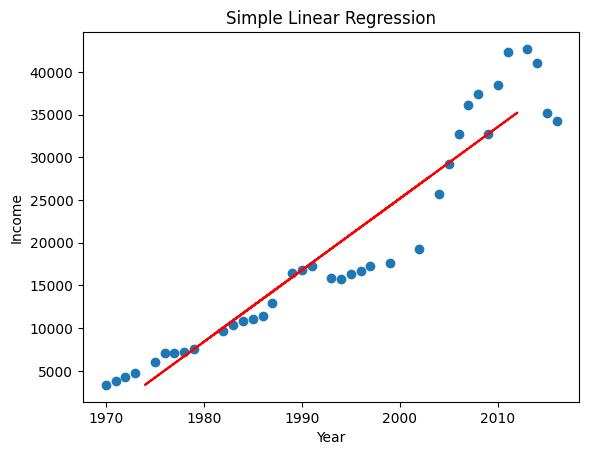

In [44]:
plt.scatter(X_train,y_train)
plt.plot(x_test,y_pred,color='r')
plt.title("Simple Linear Regression")
plt.xlabel("Year")
plt.ylabel("Income")
plt.show()

In [45]:
# Use eval_data to evaluate the model
X_eval = eval_data[['year']]
y_pred = model.predict(X_eval)

Text(0.5, 1.0, 'Predicted Income Over Years')

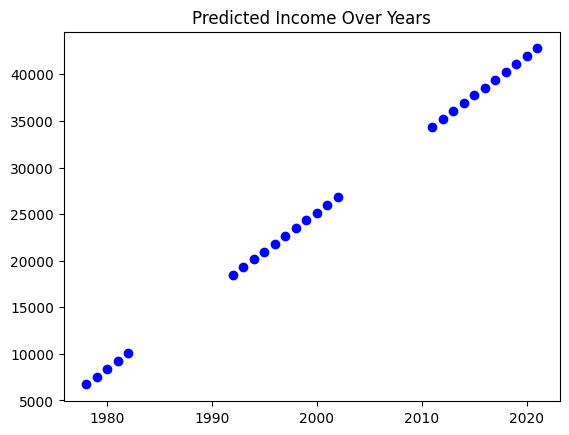

In [46]:
# Plotting the regression line
plt.scatter(X_eval, y_pred, color='blue', label='Predicted')
plt.title("Predicted Income Over Years")

In [39]:
X_eval = eval_data[['year']]
y_pred = model.predict(X_eval)

In [47]:
predictions = pd.DataFrame({'Year': eval_data['year'], 'Predicted Income': y_pred})
predictions.to_csv('prediction.csv', index=False)